# CS2 Lecture 3 — optional

안 풀어도 됨. numpy·pandas로 다차원 리스트 다뤄보는 것. 빈칸(`# ADD`)만 채우면 된다.

## 0. numpy 맛보기

`np.array` 는 다차원 리스트처럼 생겼는데 for 루프 없이 통째로 계산되고
축(axis) 방향으로 합·평균이 된다. 아래는 그냥 실행해서 결과만 보면 된다.

In [ ]:
import numpy as np


A = np.arange(12).reshape(3, 4)
print("A", A)


# for 루프 없이 이렇게 다룬다 — 실행해서 결과만 확인

print(A[:, 1])          # 1번 열
print(A.sum(axis=1))    # 각 행의 합
print(A[1:3, 1:3])      # 행 1~2, 열 1~2 부분 블록
print((A > 5).sum())    # 5 보다 큰 원소 개수


## 1. 이미지 흐리기 (box blur)

흑백 이미지 = `H×W` 2차원 리스트, `image[i][j]` 는 밝기 `0`~`255`.

Problem 6의 `countMines` 와 **구조가 똑같다** — 각 칸에서 3×3 이웃을 훑는데,
지뢰 **개수**를 세는 대신 이웃 밝기의 **합**을 구해서 이웃 수로 나눈다(평균).
그러면 이미지가 흐려진다.

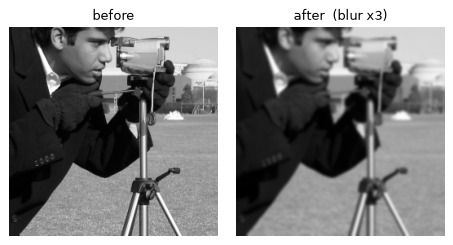

In [ ]:
import matplotlib.pyplot as plt
from skimage.data import camera


g = camera().tolist()                        # 512 x 512 2차원 리스트 (밝기 0~255)
g = [row[128:384] for row in g[128:384]]     # 256 x 256 로 자르기


def withinBoundary(height, width, i, j):
    return i >= 0 and i < height and j >= 0 and j < width


def blur(image):
    height = len(image)
    width = len(image[0])

    out = [[0.0] * width for _ in range(height)]

    for i in range(height):
        for j in range(width):
            total = 0
            count = 0

            for k in range(i - 1, i + 2):
                for w in range(j - 1, j + 2):
                    if withinBoundary(height, width, k, w):
                        pass  # ADD: total 에 image[k][w] 더하기, count 1 증가

            out[i][j] = total / count

    return out


print(blur([[0, 0, 0], [0, 9, 0], [0, 0, 0]])[1][1])   # 1.0


plt.imshow(blur(g), cmap="gray")
plt.show()


## 2. 흰 배경에서 객체만 잘라내기

Problem 7 `maxZeroRect` 는 `zeroRect(M, i1, i2, j1, j2)` ("그 사각형 안이 전부
`0` 인가?") 헬퍼를 썼다. 여기서도 같은 꼴의 헬퍼 `allWhite(g, i1, i2, j1, j2)`
("그 사각형 안이 전부 흰 배경인가?") 를 만들고, 이걸로 이미지 바깥의 흰 줄을
한 줄씩 벗겨내 객체를 감싸는 가장 작은 직사각형만 남긴다.

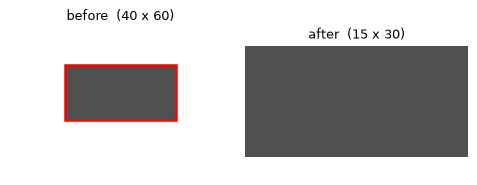

In [ ]:
import matplotlib.pyplot as plt


# 흰 배경(255) + 어두운 사각형 하나
g = [[255] * 60 for _ in range(40)]

for i in range(10, 25):
    for j in range(15, 45):
        g[i][j] = 80


def allWhite(g, i1, i2, j1, j2, thresh=250):
    # i1<=i<=i2, j1<=j<=j2 안이 전부 흰 배경이면 True  (Problem 7 zeroRect 와 같은 꼴)
    for i in range(i1, i2 + 1):
        for j in range(j1, j2 + 1):
            pass  # ADD: g[i][j] < thresh 인 게 하나라도 있으면 return False

    return True


def crop_object(g, thresh=250):
    i1, i2 = 0, len(g) - 1
    j1, j2 = 0, len(g[0]) - 1

    # 바깥쪽 흰 줄을 한 줄씩 벗겨낸다
    while i1 < i2 and allWhite(g, i1, i1, j1, j2, thresh):
        i1 += 1
    while i2 > i1 and allWhite(g, i2, i2, j1, j2, thresh):
        i2 -= 1
    while j1 < j2 and allWhite(g, i1, i2, j1, j1, thresh):
        j1 += 1
    while j2 > j1 and allWhite(g, i1, i2, j2, j2, thresh):
        j2 -= 1

    return [row[j1:j2 + 1] for row in g[i1:i2 + 1]]


crop = crop_object(g)
print(len(g), "x", len(g[0]), " -> ", len(crop), "x", len(crop[0]))   # 40 x 60  ->  15 x 30

# 마지막 잘라내기는 numpy 로:  np.array(g)[i1:i2+1, j1:j2+1]

plt.imshow(crop, cmap="gray", vmin=0, vmax=255)
plt.show()


## 3. 주가 = 시간 × 종목 2차원 리스트

인터넷에서 주가 표를 받아 한 종목의 종가 리스트를 만든다. 20일 이동평균을
구한다 — 시간축으로 이웃 평균이니 1번 blur 의 1차원 버전이다.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


URL = "https://raw.githubusercontent.com/plotly/datasets/master/stockdata.csv"

try:
    price = pd.read_csv(URL)["AAPL"].tail(300).tolist()
except Exception:
    price = (100 + np.random.default_rng(0).normal(0, 1, 300).cumsum()).tolist()


def moving_avg(col, w):
    out = np.zeros(len(col))  # out = [0.0] * len(col)

    for t in range(len(col)):
        lo = max(0, t - w + 1)
        pass  # ADD: col[lo..t] 의 평균을 out[t] 에

    return out


plt.plot(price, lw=.8)
plt.plot(moving_avg(price, 20))
plt.show()
